# Problem Set A --- Python Foundations (Weeks 1--2)

**Course:** Programming and Numerical Methods for Economics (ECNM10115)
**University of Edinburgh**

| Question | Topic | Marks |
|:--------:|:------|:-----:|
| 1 | Lists and basic operations (GDP growth rates) | 10 |
| 2 | NumPy arrays and vectorised operations (manufacturing/services) | 10 |
| 3 | Functions and economic applications (Cobb--Douglas) | 10 |
| 4 | Conditionals, loops, and dictionaries (GDP per capita) | 10 |
| 5 | Numerical integration and while loops (consumer surplus) | 10 |
| 6 | Tuples, unpacking, and a mini project (bond valuation) | 10 |
| 7 | List comprehensions and lambda functions (tax schedules) | 10 |
| 8 | Recursion and dynamic economic problems | 10 |
| 9 | Error handling and robust economic code | 10 |
| 10 | Capstone: building a simple economic simulator | 10 |
| | **Total** | **100** |

**This version includes solutions.**


In [1]:
import numpy as np

---

## Question 1 --- Lists and Basic Operations (GDP Growth Rates) [10 marks]

The following list contains the annual real GDP growth rates (in %) for the United Kingdom
from 2014 to 2023:

```python
growth_rates = [2.95, 2.35, 1.74, 1.74, 1.25, 1.64, -11.03, 7.59, 4.07, 0.10]
years = list(range(2014, 2024))
```


**(a)** [2 marks] Create the two lists above. Print the growth rate for 2020 using indexing,
and print the growth rates from 2018 to 2021 (inclusive) using slicing.


In [2]:
# --- Solution ---
growth_rates = [2.95, 2.35, 1.74, 1.74, 1.25, 1.64, -11.03, 7.59, 4.07, 0.10]
years = list(range(2014, 2024))

# 2020 is index 6
print(f"GDP growth in 2020: {growth_rates[6]}%")

# 2018-2021 is indices 4 to 7 (inclusive), so slice [4:8]
print(f"Growth rates 2018-2021: {growth_rates[4:8]}")


GDP growth in 2020: -11.03%
Growth rates 2018-2021: [1.25, 1.64, -11.03, 7.59]


**(b)** [3 marks] Using only list methods and built-in functions (no NumPy), compute and print:

1. The mean growth rate over the full period.
2. The maximum and minimum growth rates, and the years in which they occurred.
3. The number of years with negative growth.


In [3]:
# --- Solution ---
growth_rates = [2.95, 2.35, 1.74, 1.74, 1.25, 1.64, -11.03, 7.59, 4.07, 0.10]
years = list(range(2014, 2024))

# 1. Mean
mean_growth = sum(growth_rates) / len(growth_rates)
print(f"Mean growth rate: {mean_growth:.2f}%")

# 2. Max and min with years
max_growth = max(growth_rates)
min_growth = min(growth_rates)
max_year = years[growth_rates.index(max_growth)]
min_year = years[growth_rates.index(min_growth)]
print(f"Maximum growth: {max_growth}% in {max_year}")
print(f"Minimum growth: {min_growth}% in {min_year}")

# 3. Number of years with negative growth
neg_count = 0
for g in growth_rates:
    if g < 0:
        neg_count += 1
print(f"Number of years with negative growth: {neg_count}")


Mean growth rate: 1.24%
Maximum growth: 7.59% in 2021
Minimum growth: -11.03% in 2020
Number of years with negative growth: 1


**(c)** [2 marks] Create a new list called `cumulative_growth` where each element is the
cumulative product of $(1 + g_t/100)$ up to that year. That is, if
$G_t = \prod_{s=0}^{t}(1 + g_s/100)$, store $G_t$ for each $t$.
Print the final cumulative growth factor.


In [4]:
# --- Solution ---
growth_rates = [2.95, 2.35, 1.74, 1.74, 1.25, 1.64, -11.03, 7.59, 4.07, 0.10]

cumulative_growth = []
product = 1.0
for g in growth_rates:
    product *= (1 + g / 100)
    cumulative_growth.append(product)

print(f"Cumulative growth factors: {[round(x, 4) for x in cumulative_growth]}")
print(f"Final cumulative growth factor: {cumulative_growth[-1]:.4f}")


Cumulative growth factors: [1.0295, 1.0537, 1.072, 1.0907, 1.1043, 1.1224, 0.9986, 1.0744, 1.1181, 1.1193]
Final cumulative growth factor: 1.1193


**(d)** [3 marks] Write a `for` loop that pairs each year with its growth rate and prints a
formatted string. Then sort the growth rates from lowest to highest **without modifying**
the original list, and print the sorted list together with the corresponding sorted years.


In [5]:
# --- Solution ---
growth_rates = [2.95, 2.35, 1.74, 1.74, 1.25, 1.64, -11.03, 7.59, 4.07, 0.10]
years = list(range(2014, 2024))

# Print year-growth pairs
for i in range(len(years)):
    print(f"{years[i]}: {growth_rates[i]:>7.2f}%")

# Sort without modifying original
paired = list(zip(growth_rates, years))
paired.sort()
sorted_rates = [p[0] for p in paired]
sorted_years = [p[1] for p in paired]
print(f"\nSorted growth rates: {sorted_rates}")
print(f"Corresponding years: {sorted_years}")
print(f"Original list unchanged: {growth_rates}")


2014:    2.95%
2015:    2.35%
2016:    1.74%
2017:    1.74%
2018:    1.25%
2019:    1.64%
2020:  -11.03%
2021:    7.59%
2022:    4.07%
2023:    0.10%

Sorted growth rates: [-11.03, 0.1, 1.25, 1.64, 1.74, 1.74, 2.35, 2.95, 4.07, 7.59]
Corresponding years: [2020, 2023, 2018, 2019, 2016, 2017, 2015, 2014, 2022, 2021]
Original list unchanged: [2.95, 2.35, 1.74, 1.74, 1.25, 1.64, -11.03, 7.59, 4.07, 0.1]


---

## Question 2 --- NumPy Arrays and Vectorised Operations (Manufacturing and Services Output) [10 marks]

A small economy has two sectors: manufacturing and services. Quarterly output
(in billions of GBP) over 8 quarters is given below:

```python
manufacturing = np.array([12.1, 11.8, 12.5, 13.0, 12.7, 13.2, 13.5, 14.0])
services = np.array([25.3, 25.8, 26.1, 26.5, 27.0, 27.3, 27.8, 28.5])
```


**(a)** [2 marks] Create the two NumPy arrays above. Compute and print the total output
(manufacturing + services) for each quarter using vectorised addition.


In [6]:
# --- Solution ---
import numpy as np

manufacturing = np.array([12.1, 11.8, 12.5, 13.0, 12.7, 13.2, 13.5, 14.0])
services = np.array([25.3, 25.8, 26.1, 26.5, 27.0, 27.3, 27.8, 28.5])

total_output = manufacturing + services
print(f"Total output per quarter: {total_output}")


Total output per quarter: [37.4 37.6 38.6 39.5 39.7 40.5 41.3 42.5]


**(b)** [2 marks] Compute the share of manufacturing in total output for each quarter
(as a percentage). Print the mean manufacturing share.


In [7]:
# --- Solution ---
manufacturing = np.array([12.1, 11.8, 12.5, 13.0, 12.7, 13.2, 13.5, 14.0])
services = np.array([25.3, 25.8, 26.1, 26.5, 27.0, 27.3, 27.8, 28.5])

total_output = manufacturing + services
mfg_share = (manufacturing / total_output) * 100
print(f"Manufacturing share per quarter (%): {np.round(mfg_share, 2)}")
print(f"Mean manufacturing share: {mfg_share.mean():.2f}%")


Manufacturing share per quarter (%): [32.35 31.38 32.38 32.91 31.99 32.59 32.69 32.94]
Mean manufacturing share: 32.41%


**(c)** [2 marks] Compute the quarter-on-quarter growth rate for each sector using the formula:

$$g_t = \frac{X_t - X_{t-1}}{X_{t-1}} \times 100$$

Print both arrays of growth rates (each should have 7 elements).


In [8]:
# --- Solution ---
manufacturing = np.array([12.1, 11.8, 12.5, 13.0, 12.7, 13.2, 13.5, 14.0])
services = np.array([25.3, 25.8, 26.1, 26.5, 27.0, 27.3, 27.8, 28.5])

mfg_growth = (manufacturing[1:] - manufacturing[:-1]) / manufacturing[:-1] * 100
svc_growth = (services[1:] - services[:-1]) / services[:-1] * 100

print(f"Manufacturing growth rates (%): {np.round(mfg_growth, 2)}")
print(f"Services growth rates (%):      {np.round(svc_growth, 2)}")


Manufacturing growth rates (%): [-2.48  5.93  4.   -2.31  3.94  2.27  3.7 ]
Services growth rates (%):      [1.98 1.16 1.53 1.89 1.11 1.83 2.52]


**(d)** [2 marks] Use Boolean indexing to find and print all quarters (0-indexed) where
manufacturing output exceeded 13.0 billion. Also find quarters where **both** sectors
grew (i.e., both growth rates from part (c) are positive).


In [9]:
# --- Solution ---
manufacturing = np.array([12.1, 11.8, 12.5, 13.0, 12.7, 13.2, 13.5, 14.0])
services = np.array([25.3, 25.8, 26.1, 26.5, 27.0, 27.3, 27.8, 28.5])

# Quarters where manufacturing > 13.0
mask_mfg = manufacturing > 13.0
quarters_above = np.where(mask_mfg)[0]
print(f"Quarters where manufacturing > 13.0: {quarters_above}")
print(f"Values: {manufacturing[mask_mfg]}")

# Quarters where both sectors grew
mfg_growth = (manufacturing[1:] - manufacturing[:-1]) / manufacturing[:-1] * 100
svc_growth = (services[1:] - services[:-1]) / services[:-1] * 100

both_grew = np.where((mfg_growth > 0) & (svc_growth > 0))[0]
# These indices refer to the growth array, so quarter index is +1
print(f"Quarters where both sectors grew (growth array index): {both_grew}")


Quarters where manufacturing > 13.0: [5 6 7]
Values: [13.2 13.5 14. ]
Quarters where both sectors grew (growth array index): [1 2 4 5 6]


**(e)** [2 marks] Stack the two arrays into a $2 \times 8$ matrix using `np.vstack`.
Compute the column-wise mean (i.e., the average across sectors for each quarter) and
the row-wise mean (i.e., the average across quarters for each sector). Print both.


In [10]:
# --- Solution ---
manufacturing = np.array([12.1, 11.8, 12.5, 13.0, 12.7, 13.2, 13.5, 14.0])
services = np.array([25.3, 25.8, 26.1, 26.5, 27.0, 27.3, 27.8, 28.5])

output_matrix = np.vstack([manufacturing, services])
print(f"Output matrix shape: {output_matrix.shape}")
print(f"Output matrix:\n{output_matrix}")

col_mean = output_matrix.mean(axis=0)
row_mean = output_matrix.mean(axis=1)
print(f"\nColumn-wise mean (avg across sectors per quarter): {np.round(col_mean, 2)}")
print(f"Row-wise mean (avg across quarters per sector):     {np.round(row_mean, 2)}")


Output matrix shape: (2, 8)
Output matrix:
[[12.1 11.8 12.5 13.  12.7 13.2 13.5 14. ]
 [25.3 25.8 26.1 26.5 27.  27.3 27.8 28.5]]

Column-wise mean (avg across sectors per quarter): [18.7  18.8  19.3  19.75 19.85 20.25 20.65 21.25]
Row-wise mean (avg across quarters per sector):     [12.85 26.79]


---

## Question 3 --- Functions and Economic Applications (Cobb--Douglas) [10 marks]

The Cobb--Douglas production function is given by:

$$Y = A \, K^{\alpha} \, L^{1-\alpha}$$

where $Y$ is output, $A$ is total factor productivity (TFP), $K$ is capital,
$L$ is labour, and $\alpha \in (0,1)$ is the capital share.


**(a)** [3 marks] Write a function `cobb_douglas(A, K, L, alpha)` that returns $Y$.
The function should:
- Have a default value of $\alpha = 0.33$.
- Raise a `ValueError` if $\alpha \notin (0, 1)$.
- Accept both scalar and NumPy array inputs for $K$ and $L$.

Test it with $A=1$, $K=100$, $L=200$, $\alpha=0.33$.


In [11]:
# --- Solution ---
import numpy as np

def cobb_douglas(A, K, L, alpha=0.33):
    """Compute output from a Cobb-Douglas production function."""
    if alpha <= 0 or alpha >= 1:
        raise ValueError(f"alpha must be in (0, 1), got {alpha}")
    return A * K**alpha * L**(1 - alpha)

# Test
Y = cobb_douglas(1, 100, 200, 0.33)
print(f"Y = {Y:.2f}")


Y = 159.11


**(b)** [3 marks] The marginal product of capital (MPK) is:

$$\text{MPK} = \alpha \, A \, K^{\alpha - 1} \, L^{1 - \alpha}$$

Write a function `mpk(A, K, L, alpha)` that returns the MPK.
Using $A = 1$, $L = 200$, and $\alpha = 0.33$, compute and print the MPK
for $K = 50, 100, 150, 200, 250$. Verify that the MPK is **diminishing** in $K$.


In [12]:
# --- Solution ---
import numpy as np

def cobb_douglas(A, K, L, alpha=0.33):
    if alpha <= 0 or alpha >= 1:
        raise ValueError(f"alpha must be in (0, 1), got {alpha}")
    return A * K**alpha * L**(1 - alpha)

def mpk(A, K, L, alpha=0.33):
    """Compute the marginal product of capital."""
    return alpha * A * K**(alpha - 1) * L**(1 - alpha)

K_values = np.array([50, 100, 150, 200, 250])
mpk_values = mpk(1, K_values, 200, 0.33)
print("K      | MPK")
print("-------|--------")
for k, m in zip(K_values, mpk_values):
    print(f"{k:>6} | {m:.4f}")

# Verify diminishing MPK
is_diminishing = all(mpk_values[i] > mpk_values[i+1] for i in range(len(mpk_values)-1))
print(f"\nMPK is diminishing: {is_diminishing}")


K      | MPK
-------|--------
    50 | 0.8354
   100 | 0.5251
   150 | 0.4002
   200 | 0.3300
   250 | 0.2842

MPK is diminishing: True


**(c)** [4 marks] A production function exhibits:
- **Constant returns to scale (CRS)** if $Y(\lambda K, \lambda L) = \lambda \, Y(K, L)$
- **Increasing returns to scale (IRS)** if $Y(\lambda K, \lambda L) > \lambda \, Y(K, L)$
- **Decreasing returns to scale (DRS)** if $Y(\lambda K, \lambda L) < \lambda \, Y(K, L)$

Write a function `check_returns_to_scale(A, K, L, alpha, lam=2)` that:
1. Computes $Y(K, L)$ and $Y(\lambda K, \lambda L)$.
2. Compares $Y(\lambda K, \lambda L)$ with $\lambda \, Y(K, L)$.
3. Returns a string: `"CRS"`, `"IRS"`, or `"DRS"`.

Test it with $\alpha = 0.33$ (standard Cobb--Douglas) and with a modified production
function $Y = A K^{0.4} L^{0.7}$ (where exponents sum to $1.1 > 1$).

*Hint:* Use a small tolerance (e.g., $10^{-9}$) for floating-point comparison.


In [13]:
# --- Solution ---
import numpy as np

def cobb_douglas(A, K, L, alpha=0.33):
    if alpha <= 0 or alpha >= 1:
        raise ValueError(f"alpha must be in (0, 1), got {alpha}")
    return A * K**alpha * L**(1 - alpha)

def general_production(A, K, L, alpha, beta):
    """General production function Y = A * K^alpha * L^beta."""
    return A * K**alpha * L**beta

def check_returns_to_scale(prod_func, A, K, L, lam=2, tol=1e-9, **kwargs):
    """Check returns to scale for a given production function."""
    Y_original = prod_func(A, K, L, **kwargs)
    Y_scaled = prod_func(A, lam * K, lam * L, **kwargs)

    if abs(Y_scaled - lam * Y_original) < tol:
        return "CRS"
    elif Y_scaled > lam * Y_original:
        return "IRS"
    else:
        return "DRS"

# Test 1: Standard Cobb-Douglas (alpha + (1-alpha) = 1 -> CRS)
result1 = check_returns_to_scale(cobb_douglas, A=1, K=100, L=200, alpha=0.33)
print(f"Standard Cobb-Douglas (alpha=0.33): {result1}")

# Test 2: Modified with exponents summing to 1.1 -> IRS
result2 = check_returns_to_scale(
    general_production, A=1, K=100, L=200, alpha=0.4, beta=0.7
)
print(f"Modified (alpha=0.4, beta=0.7, sum=1.1): {result2}")

# Test 3: Exponents summing to 0.8 -> DRS
result3 = check_returns_to_scale(
    general_production, A=1, K=100, L=200, alpha=0.3, beta=0.5
)
print(f"Modified (alpha=0.3, beta=0.5, sum=0.8): {result3}")


Standard Cobb-Douglas (alpha=0.33): CRS
Modified (alpha=0.4, beta=0.7, sum=1.1): IRS
Modified (alpha=0.3, beta=0.5, sum=0.8): DRS


---

## Question 4 --- Conditionals, Loops, and Dictionaries (GDP Per Capita Classification) [10 marks]

The World Bank classifies economies by gross national income (GNI) per capita.
A simplified scheme (using GDP per capita in USD as a proxy) is:

| Category | GDP per capita range |
|:---------|:---------------------|
| Low income | $< 1{,}136$ |
| Lower-middle income | $1{,}136$ -- $4{,}465$ |
| Upper-middle income | $4{,}466$ -- $13{,}845$ |
| High income | $> 13{,}845$ |

Use the following data (2023 estimates, in USD):

```python
countries = {
    "United States": 80035,
    "Germany": 52824,
    "China": 12720,
    "Brazil": 10412,
    "India": 2612,
    "Nigeria": 1621,
    "Ethiopia": 1027,
    "United Kingdom": 48913,
    "Mexico": 13405,
    "Bangladesh": 2688
}
```


**(a)** [3 marks] Write a function `classify_income(gdp_pc)` that takes a GDP per capita
value and returns the appropriate World Bank income category as a string. Test it on at
least three values spanning different categories.


In [14]:
# --- Solution ---
def classify_income(gdp_pc):
    """Classify a country by GDP per capita using World Bank thresholds."""
    if gdp_pc < 1136:
        return "Low income"
    elif gdp_pc <= 4465:
        return "Lower-middle income"
    elif gdp_pc <= 13845:
        return "Upper-middle income"
    else:
        return "High income"

# Test
print(classify_income(500))     # Low income
print(classify_income(3000))    # Lower-middle income
print(classify_income(10000))   # Upper-middle income
print(classify_income(50000))   # High income


Low income
Lower-middle income
Upper-middle income
High income


**(b)** [3 marks] Loop through the `countries` dictionary and build a new dictionary
called `classified` where keys are the four income categories and values are **lists**
of country names in that category. Print the result.


In [15]:
# --- Solution ---
countries = {
    "United States": 80035,
    "Germany": 52824,
    "China": 12720,
    "Brazil": 10412,
    "India": 2612,
    "Nigeria": 1621,
    "Ethiopia": 1027,
    "United Kingdom": 48913,
    "Mexico": 13405,
    "Bangladesh": 2688
}

def classify_income(gdp_pc):
    if gdp_pc < 1136:
        return "Low income"
    elif gdp_pc <= 4465:
        return "Lower-middle income"
    elif gdp_pc <= 13845:
        return "Upper-middle income"
    else:
        return "High income"

classified = {
    "Low income": [],
    "Lower-middle income": [],
    "Upper-middle income": [],
    "High income": []
}

for country, gdp_pc in countries.items():
    category = classify_income(gdp_pc)
    classified[category].append(country)

for category, country_list in classified.items():
    print(f"{category}: {country_list}")


Low income: ['Ethiopia']
Lower-middle income: ['India', 'Nigeria', 'Bangladesh']
Upper-middle income: ['China', 'Brazil', 'Mexico']
High income: ['United States', 'Germany', 'United Kingdom']


**(c)** [4 marks] For each income category, compute and print:
1. The number of countries.
2. The mean GDP per capita of countries in that group.
3. The ratio of the highest to the lowest GDP per capita within the group
   (skip groups with only one country).

Finally, compute the overall **Gini-style** spread: print the ratio of the maximum
GDP per capita to the minimum GDP per capita across **all** countries.


In [16]:
# --- Solution ---
countries = {
    "United States": 80035,
    "Germany": 52824,
    "China": 12720,
    "Brazil": 10412,
    "India": 2612,
    "Nigeria": 1621,
    "Ethiopia": 1027,
    "United Kingdom": 48913,
    "Mexico": 13405,
    "Bangladesh": 2688
}

def classify_income(gdp_pc):
    if gdp_pc < 1136:
        return "Low income"
    elif gdp_pc <= 4465:
        return "Lower-middle income"
    elif gdp_pc <= 13845:
        return "Upper-middle income"
    else:
        return "High income"

# Build classified dict with GDP values
classified_values = {
    "Low income": [],
    "Lower-middle income": [],
    "Upper-middle income": [],
    "High income": []
}

for country, gdp_pc in countries.items():
    category = classify_income(gdp_pc)
    classified_values[category].append(gdp_pc)

for category, values in classified_values.items():
    n = len(values)
    if n == 0:
        print(f"{category}: no countries")
        continue
    mean_val = sum(values) / n
    print(f"\n{category}:")
    print(f"  Number of countries: {n}")
    print(f"  Mean GDP per capita: ${mean_val:,.0f}")
    if n > 1:
        ratio = max(values) / min(values)
        print(f"  Max/Min ratio within group: {ratio:.2f}")

# Overall spread
all_gdp = list(countries.values())
overall_ratio = max(all_gdp) / min(all_gdp)
print(f"\nOverall max/min ratio: {overall_ratio:.2f}")
print(f"  ({max(all_gdp):,} / {min(all_gdp):,})")



Low income:
  Number of countries: 1
  Mean GDP per capita: $1,027

Lower-middle income:
  Number of countries: 3
  Mean GDP per capita: $2,307
  Max/Min ratio within group: 1.66

Upper-middle income:
  Number of countries: 3
  Mean GDP per capita: $12,179
  Max/Min ratio within group: 1.29

High income:
  Number of countries: 3
  Mean GDP per capita: $60,591
  Max/Min ratio within group: 1.64

Overall max/min ratio: 77.93
  (80,035 / 1,027)


---

## Question 5 --- Numerical Integration and While Loops (Consumer Surplus) [10 marks]

Consider a market with inverse demand function:

$$P(Q) = 100 - 2Q$$

and a constant equilibrium price $P^* = 40$. The equilibrium quantity is therefore
$Q^* = 30$.

The **consumer surplus** is the area between the demand curve and the price line,
from $Q = 0$ to $Q = Q^*$:

$$CS = \int_0^{Q^*} \bigl[P(Q) - P^*\bigr] \, dQ$$


**(a)** [3 marks] Compute the consumer surplus **analytically** (by hand or using algebra
in Python). Then write a function `riemann_sum(f, a, b, n)` that approximates
$\int_a^b f(x)\,dx$ using a left-endpoint Riemann sum with $n$ rectangles:

$$\int_a^b f(x)\,dx \approx \sum_{i=0}^{n-1} f(x_i) \, \Delta x, \quad \Delta x = \frac{b-a}{n}, \quad x_i = a + i\,\Delta x$$

Use it to approximate the consumer surplus with $n = 100$.


In [17]:
# --- Solution ---
import numpy as np

# Analytical solution:
# CS = integral from 0 to 30 of (100 - 2Q - 40) dQ
#    = integral from 0 to 30 of (60 - 2Q) dQ
#    = [60Q - Q^2] from 0 to 30
#    = 60*30 - 30^2 - 0
#    = 1800 - 900 = 900

P_star = 40
Q_star = 30
CS_analytical = 60 * Q_star - Q_star**2
print(f"Analytical consumer surplus: {CS_analytical}")

def riemann_sum(f, a, b, n):
    """Left-endpoint Riemann sum approximation of integral of f from a to b."""
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x_i = a + i * dx
        total += f(x_i) * dx
    return total

# Define the integrand: P(Q) - P*
def cs_integrand(Q):
    return (100 - 2 * Q) - 40  # = 60 - 2Q

CS_approx = riemann_sum(cs_integrand, 0, Q_star, 100)
print(f"Riemann sum approximation (n=100): {CS_approx:.4f}")
print(f"Error: {abs(CS_approx - CS_analytical):.4f}")


Analytical consumer surplus: 900
Riemann sum approximation (n=100): 909.0000
Error: 9.0000


**(b)** [3 marks] Use a `while` loop to find the **smallest** $n$ such that the
Riemann sum approximation is within $0.01$ of the analytical answer. Start with $n = 10$
and increase $n$ by 10 in each iteration. Print the required $n$ and the corresponding
approximation.


In [18]:
# --- Solution ---
import numpy as np

def riemann_sum(f, a, b, n):
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x_i = a + i * dx
        total += f(x_i) * dx
    return total

def cs_integrand(Q):
    return (100 - 2 * Q) - 40

CS_analytical = 900.0
tolerance = 0.01

n = 10
while True:
    approx = riemann_sum(cs_integrand, 0, 30, n)
    error = abs(approx - CS_analytical)
    if error < tolerance:
        break
    n += 10

print(f"Required n: {n}")
print(f"Approximation: {approx:.6f}")
print(f"Error: {error:.6f}")


Required n: 90000
Approximation: 900.010000
Error: 0.010000


**(c)** [4 marks] Compute the Riemann sum for $n = 10, 50, 100, 500, 1000, 5000$.
Store the errors $|\text{approx} - \text{exact}|$ in a NumPy array. Verify that the
error is approximately proportional to $1/n$ (i.e., the error roughly halves when $n$
doubles) by computing the ratio $\text{error}(n) \times n$ for each value --- it
should be roughly constant. Print a table of $n$, approximation, error, and
$\text{error} \times n$.


In [19]:
# --- Solution ---
import numpy as np

def riemann_sum(f, a, b, n):
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x_i = a + i * dx
        total += f(x_i) * dx
    return total

def cs_integrand(Q):
    return (100 - 2 * Q) - 40

CS_analytical = 900.0

n_values = [10, 50, 100, 500, 1000, 5000]
approx_values = []
errors = []

for n in n_values:
    approx = riemann_sum(cs_integrand, 0, 30, n)
    err = abs(approx - CS_analytical)
    approx_values.append(approx)
    errors.append(err)

errors = np.array(errors)
n_arr = np.array(n_values)

print(f"{'n':>6} | {'Approximation':>14} | {'Error':>10} | {'Error * n':>10}")
print("-" * 50)
for i in range(len(n_values)):
    print(f"{n_values[i]:>6} | {approx_values[i]:>14.6f} | {errors[i]:>10.6f} | {(errors[i] * n_values[i]):>10.4f}")

print(f"\nError * n is approximately constant, confirming O(1/n) convergence.")


     n |  Approximation |      Error |  Error * n
--------------------------------------------------
    10 |     990.000000 |  90.000000 |   900.0000
    50 |     918.000000 |  18.000000 |   900.0000
   100 |     909.000000 |   9.000000 |   900.0000
   500 |     901.800000 |   1.800000 |   900.0000
  1000 |     900.900000 |   0.900000 |   900.0000
  5000 |     900.180000 |   0.180000 |   900.0000

Error * n is approximately constant, confirming O(1/n) convergence.


---

## Question 6 --- Tuples, Unpacking, and a Mini Project (Bond Valuation) [10 marks]

A **zero-coupon bond** pays no coupons and returns its face value $F$ at maturity.
Its present value is:

$$PV = \frac{F}{(1 + r)^T}$$

A **coupon bond** pays an annual coupon $C$ for $T$ years and returns the face value
at maturity. Its present value is:

$$PV = \sum_{t=1}^{T} \frac{C}{(1+r)^t} + \frac{F}{(1+r)^T}$$

where $r$ is the annual discount rate (yield to maturity).


**(a)** [3 marks] Define a tuple `bond_params` containing $(F, C, T, r) = (1000, 50, 10, 0.04)$.
Unpack it into four named variables. Print each parameter with a descriptive label.
Then create a list of three bond tuples with different maturities: $T = 5, 10, 20$
(keeping $F$, $C$, and $r$ the same).


In [20]:
# --- Solution ---
# Define and unpack bond parameters
bond_params = (1000, 50, 10, 0.04)
F, C, T, r = bond_params

print(f"Face value (F): ${F}")
print(f"Annual coupon (C): ${C}")
print(f"Maturity (T): {T} years")
print(f"Yield to maturity (r): {r:.2%}")

# List of bond tuples with different maturities
bonds = [
    (1000, 50, 5, 0.04),
    (1000, 50, 10, 0.04),
    (1000, 50, 20, 0.04)
]
print(f"\nBond tuples: {bonds}")


Face value (F): $1000
Annual coupon (C): $50
Maturity (T): 10 years
Yield to maturity (r): 4.00%

Bond tuples: [(1000, 50, 5, 0.04), (1000, 50, 10, 0.04), (1000, 50, 20, 0.04)]


**(b)** [3 marks] Write a function `bond_price(F, C, T, r)` that computes the present
value of a coupon bond. The function should:
- Return a **tuple** `(price, coupon_pv, face_pv)` where `coupon_pv` is the present
  value of all coupon payments and `face_pv` is the present value of the face value.
- Handle the special case $C = 0$ (zero-coupon bond).

Test it on the three bonds from part (a) and print the results in a formatted table.


In [21]:
# --- Solution ---
def bond_price(F, C, T, r):
    """Compute the present value of a coupon bond.

    Returns (price, coupon_pv, face_pv).
    """
    # PV of face value
    face_pv = F / (1 + r)**T

    # PV of coupons
    coupon_pv = 0.0
    for t in range(1, T + 1):
        coupon_pv += C / (1 + r)**t

    price = coupon_pv + face_pv
    return (price, coupon_pv, face_pv)

# Test on three bonds
bonds = [
    (1000, 50, 5, 0.04),
    (1000, 50, 10, 0.04),
    (1000, 50, 20, 0.04)
]

print(f"{'T':>3} | {'Price':>10} | {'Coupon PV':>10} | {'Face PV':>10}")
print("-" * 42)
for bond in bonds:
    F, C, T, r = bond
    price, cpv, fpv = bond_price(F, C, T, r)
    print(f"{T:>3} | ${price:>9.2f} | ${cpv:>9.2f} | ${fpv:>9.2f}")


  T |      Price |  Coupon PV |    Face PV
------------------------------------------
  5 | $  1044.52 | $   222.59 | $   821.93
 10 | $  1081.11 | $   405.54 | $   675.56
 20 | $  1135.90 | $   679.52 | $   456.39


**(c)** [4 marks] A bond is trading at **par** when its price equals its face value.
Write a function `find_par_yield(F, C, T, r_low=0.001, r_high=0.20, tol=1e-6)` that
uses a **bisection method** (a `while` loop) to find the yield $r$ at which the bond
trades at par. The bisection algorithm is:

1. Set $r_{\text{mid}} = (r_{\text{low}} + r_{\text{high}}) / 2$.
2. If $\text{price}(r_{\text{mid}}) > F$, increase $r_{\text{low}}$; otherwise decrease $r_{\text{high}}$.
3. Repeat until $|\text{price}(r_{\text{mid}}) - F| < \text{tol}$.

Test it with $F = 1000$, $C = 50$, $T = 10$. The par yield should be close to the
coupon rate ($C/F = 5\%$). Print the par yield and the number of iterations needed.


In [22]:
# --- Solution ---
def bond_price(F, C, T, r):
    face_pv = F / (1 + r)**T
    coupon_pv = sum(C / (1 + r)**t for t in range(1, T + 1))
    return coupon_pv + face_pv

def find_par_yield(F, C, T, r_low=0.001, r_high=0.20, tol=1e-6):
    """Find the yield at which a bond trades at par using bisection."""
    iterations = 0
    while r_high - r_low > tol:
        r_mid = (r_low + r_high) / 2
        price = bond_price(F, C, T, r_mid)
        if price > F:
            r_low = r_mid   # price too high -> yield too low
        else:
            r_high = r_mid  # price too low -> yield too high
        iterations += 1

    r_mid = (r_low + r_high) / 2
    return r_mid, iterations

F, C, T = 1000, 50, 10
par_yield, iters = find_par_yield(F, C, T)
par_price = bond_price(F, C, T, par_yield)

print(f"Par yield: {par_yield:.6f} ({par_yield*100:.4f}%)")
print(f"Coupon rate: {C/F:.4f} ({C/F*100:.2f}%)")
print(f"Price at par yield: ${par_price:.4f}")
print(f"Iterations needed: {iters}")
print(f"\nAs expected, the par yield is approximately equal to the coupon rate.")


Par yield: 0.050000 (5.0000%)
Coupon rate: 0.0500 (5.00%)
Price at par yield: $999.9972
Iterations needed: 18

As expected, the par yield is approximately equal to the coupon rate.


---

## Question 7 --- List Comprehensions and Lambda Functions (Tax Schedules) [10 marks]

This question tests your fluency with Pythonic idioms: list comprehensions,
`lambda` functions, `map`, `filter`, and the `time` module.


**(a)** [3 marks] You are given a list of annual incomes (in GBP) for a sample of
households:

```python
incomes = [12500, 18200, 24800, 35600, 48900, 52100, 67300, 85400, 112000, 155000]
```

Using **only list comprehensions** (no explicit `for` loops), create:
1. A list of incomes above the median income.
2. A list of tuples `(income, tax_bracket)` where `tax_bracket` is `"basic"` if income
   $\leq 50{,}270$, `"higher"` if income $\leq 125{,}140$, and `"additional"` otherwise.
3. A list of after-tax incomes using a flat 20% tax rate on income above the personal
   allowance of $\pounds 12{,}570$.


In [23]:
# --- Solution ---
incomes = [12500, 18200, 24800, 35600, 48900, 52100, 67300, 85400, 112000, 155000]

# 1. Incomes above the median
sorted_inc = sorted(incomes)
n = len(sorted_inc)
median_inc = (sorted_inc[n//2 - 1] + sorted_inc[n//2]) / 2
above_median = [inc for inc in incomes if inc > median_inc]
print(f"Median income: {median_inc}")
print(f"Incomes above median: {above_median}")

# 2. Income-bracket tuples
bracket_tuples = [
    (inc, "basic" if inc <= 50270 else ("higher" if inc <= 125140 else "additional"))
    for inc in incomes
]
print(f"\nIncome-bracket tuples:")
for t in bracket_tuples:
    print(f"  {t}")

# 3. After-tax incomes (flat 20% above personal allowance of 12570)
personal_allowance = 12570
after_tax = [inc - 0.20 * max(0, inc - personal_allowance) for inc in incomes]
print(f"\nAfter-tax incomes: {after_tax}")


Median income: 50500.0
Incomes above median: [52100, 67300, 85400, 112000, 155000]

Income-bracket tuples:
  (12500, 'basic')
  (18200, 'basic')
  (24800, 'basic')
  (35600, 'basic')
  (48900, 'basic')
  (52100, 'higher')
  (67300, 'higher')
  (85400, 'higher')
  (112000, 'higher')
  (155000, 'additional')

After-tax incomes: [12500.0, 17074.0, 22354.0, 30994.0, 41634.0, 44194.0, 56354.0, 70834.0, 92114.0, 126514.0]


**(b)** [3 marks] The UK income tax schedule (simplified, 2023--24) is:

| Band | Taxable income | Rate |
|:-----|:---------------|:-----|
| Personal allowance | Up to $\pounds 12{,}570$ | 0% |
| Basic rate | $\pounds 12{,}571$ -- $\pounds 50{,}270$ | 20% |
| Higher rate | $\pounds 50{,}271$ -- $\pounds 125{,}140$ | 40% |
| Additional rate | Over $\pounds 125{,}140$ | 45% |

Write a `lambda` function called `tax_owed` that computes the total tax for a given
income under this **progressive** schedule. Then use `map` to apply it to all incomes
in the list from part (a). Print each income alongside its tax and effective tax rate.

*Hint:* A `lambda` can call a helper function if the logic is complex.


In [24]:
# --- Solution ---
incomes = [12500, 18200, 24800, 35600, 48900, 52100, 67300, 85400, 112000, 155000]

def compute_tax(income):
    """Compute UK income tax under 2023-24 simplified bands."""
    tax = 0
    if income > 125140:
        tax += (income - 125140) * 0.45
        income = 125140
    if income > 50270:
        tax += (income - 50270) * 0.40
        income = 50270
    if income > 12570:
        tax += (income - 12570) * 0.20
    return tax

# Lambda wrapping the helper
tax_owed = lambda inc: compute_tax(inc)

# Apply with map
taxes = list(map(tax_owed, incomes))

print(f"{'Income':>10} | {'Tax':>10} | {'Effective Rate':>14}")
print("-" * 40)
for inc, tax in zip(incomes, taxes):
    rate = (tax / inc * 100) if inc > 0 else 0
    print(f"{inc:>10,} | {tax:>10,.2f} | {rate:>13.2f}%")


    Income |        Tax | Effective Rate
----------------------------------------
    12,500 |       0.00 |          0.00%
    18,200 |   1,126.00 |          6.19%
    24,800 |   2,446.00 |          9.86%
    35,600 |   4,606.00 |         12.94%
    48,900 |   7,266.00 |         14.86%
    52,100 |   8,272.00 |         15.88%
    67,300 |  14,352.00 |         21.33%
    85,400 |  21,592.00 |         25.28%
   112,000 |  32,232.00 |         28.78%
   155,000 |  50,925.00 |         32.85%


**(c)** [4 marks] Compare the performance of a list comprehension versus an explicit
`for` loop for computing the square of each element in a large list.

1. Create a list of integers from 0 to 999,999.
2. Time how long a `for` loop takes to build a list of squares.
3. Time how long a list comprehension takes.
4. Time how long a NumPy vectorised operation takes (`np.arange(1_000_000)**2`).

Use the `time` module (specifically `time.time()`) and repeat each operation 5 times,
reporting the average. Print the results and the speed-up ratios.


In [25]:
# --- Solution ---
import time
import numpy as np

N = 1_000_000
repeats = 5

# Method 1: Explicit for loop
times_loop = []
for _ in range(repeats):
    data = list(range(N))
    start = time.time()
    result = []
    for x in data:
        result.append(x**2)
    end = time.time()
    times_loop.append(end - start)

# Method 2: List comprehension
times_comp = []
for _ in range(repeats):
    data = list(range(N))
    start = time.time()
    result = [x**2 for x in data]
    end = time.time()
    times_comp.append(end - start)

# Method 3: NumPy vectorised
times_numpy = []
for _ in range(repeats):
    start = time.time()
    data = np.arange(N)
    result = data**2
    end = time.time()
    times_numpy.append(end - start)

avg_loop = sum(times_loop) / repeats
avg_comp = sum(times_comp) / repeats
avg_numpy = sum(times_numpy) / repeats

print(f"Average times over {repeats} repeats (N = {N:,}):")
print(f"  For loop:          {avg_loop:.4f} s")
print(f"  List comprehension: {avg_comp:.4f} s")
print(f"  NumPy vectorised:  {avg_numpy:.4f} s")
print(f"\nSpeed-up ratios (relative to for loop):")
print(f"  Comprehension: {avg_loop/avg_comp:.2f}x faster")
print(f"  NumPy:         {avg_loop/avg_numpy:.2f}x faster")


Average times over 5 repeats (N = 1,000,000):
  For loop:          0.1457 s
  List comprehension: 0.0616 s
  NumPy vectorised:  0.0052 s

Speed-up ratios (relative to for loop):
  Comprehension: 2.37x faster
  NumPy:         28.25x faster


---

## Question 8 --- Recursion and Dynamic Economic Problems [10 marks]

This question explores recursive programming in the context of economic applications.
Recall that a **recursive function** is one that calls itself, and must have a **base case**
to prevent infinite recursion.


**(a)** [2 marks] Write a recursive function `compound_interest(P, r, n)` that computes
the future value of a principal $P$ after $n$ periods at interest rate $r$ per period,
using the recurrence:

$$FV(n) = \begin{cases} P & \text{if } n = 0 \\ FV(n-1) \times (1 + r) & \text{if } n > 0 \end{cases}$$

Test it with $P = 1000$, $r = 0.05$, $n = 10$ and verify against the closed-form
$FV = P(1+r)^n$.


In [26]:
# --- Solution ---
def compound_interest(P, r, n):
    """Recursively compute compound interest."""
    if n == 0:
        return P
    return compound_interest(P, r, n - 1) * (1 + r)

# Test
P, r, n = 1000, 0.05, 10
recursive_fv = compound_interest(P, r, n)
closed_form_fv = P * (1 + r)**n

print(f"Recursive FV:    {recursive_fv:.4f}")
print(f"Closed-form FV:  {closed_form_fv:.4f}")
print(f"Match: {abs(recursive_fv - closed_form_fv) < 1e-9}")


Recursive FV:    1628.8946
Closed-form FV:  1628.8946
Match: True


**(b)** [3 marks] The Fibonacci sequence $F(n) = F(n-1) + F(n-2)$ with $F(0) = 0$,
$F(1) = 1$ has connections to population growth models (e.g., Fibonacci's original
rabbit problem).

1. Write a recursive function `fibonacci(n)` that returns the $n$-th Fibonacci number.
2. Write an iterative version `fibonacci_iter(n)` using a loop.
3. Time both for $n = 30$ and compare. Explain (in a comment or print statement) why
   the recursive version is slower.


In [27]:
# --- Solution ---
import time

def fibonacci(n):
    """Recursive Fibonacci (naive, exponential time)."""
    if n <= 0:
        return 0
    if n == 1:
        return 1
    return fibonacci(n - 1) + fibonacci(n - 2)

def fibonacci_iter(n):
    """Iterative Fibonacci (linear time)."""
    if n <= 0:
        return 0
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

n = 30

# Time recursive
start = time.time()
fib_rec = fibonacci(n)
time_rec = time.time() - start

# Time iterative
start = time.time()
fib_iter = fibonacci_iter(n)
time_iter = time.time() - start

print(f"fibonacci({n}) = {fib_rec}")
print(f"fibonacci_iter({n}) = {fib_iter}")
print(f"\nRecursive time: {time_rec:.4f} s")
print(f"Iterative time: {time_iter:.6f} s")
print(f"Speed-up: {time_rec / max(time_iter, 1e-10):.0f}x")

print("\nThe naive recursive version is exponentially slow because it recomputes")
print("the same subproblems many times (overlapping subproblems). The call tree")
print("has O(2^n) nodes. The iterative version runs in O(n) time.")


fibonacci(30) = 832040
fibonacci_iter(30) = 832040

Recursive time: 0.1252 s
Iterative time: 0.000046 s
Speed-up: 2722x

The naive recursive version is exponentially slow because it recomputes
the same subproblems many times (overlapping subproblems). The call tree
has O(2^n) nodes. The iterative version runs in O(n) time.


**(c)** [2 marks] Write a recursive function `binary_search(arr, target, low, high)` that
searches for `target` in a sorted array `arr` between indices `low` and `high`.
Return the index if found, or $-1$ if not found.

Test it on the following sorted list of commodity prices:

```python
prices = [12.5, 15.3, 18.7, 22.1, 25.6, 30.0, 35.4, 42.8, 51.2, 60.0]
```

Search for the price $30.0$ (should be found) and $29.0$ (should not be found).


In [28]:
# --- Solution ---
def binary_search(arr, target, low, high):
    """Recursive binary search. Returns index if found, -1 otherwise."""
    if low > high:
        return -1
    mid = (low + high) // 2
    if arr[mid] == target:
        return mid
    elif arr[mid] < target:
        return binary_search(arr, target, mid + 1, high)
    else:
        return binary_search(arr, target, low, mid - 1)

prices = [12.5, 15.3, 18.7, 22.1, 25.6, 30.0, 35.4, 42.8, 51.2, 60.0]

# Search for 30.0
idx1 = binary_search(prices, 30.0, 0, len(prices) - 1)
print(f"Search for 30.0: index = {idx1}, value = {prices[idx1]}")

# Search for 29.0
idx2 = binary_search(prices, 29.0, 0, len(prices) - 1)
print(f"Search for 29.0: index = {idx2} (not found)")


Search for 30.0: index = 5, value = 30.0
Search for 29.0: index = -1 (not found)


**(d)** [3 marks] Python has a default recursion limit (typically 1000). Write a
recursive function `sum_series(n)` that computes $\sum_{i=1}^{n} i$ recursively.

1. Test it for $n = 500$ and verify against the closed-form $n(n+1)/2$.
2. Show what happens when $n$ exceeds the recursion limit by trying $n = 1500$
   inside a `try`/`except RecursionError` block.
3. Write an iterative version that works for any $n$ and test with $n = 100{,}000$.

Discuss in a comment when recursion is appropriate and when iteration is preferred.


In [29]:
# --- Solution ---
import sys

def sum_series(n):
    """Recursively compute sum of 1 + 2 + ... + n."""
    if n <= 0:
        return 0
    return n + sum_series(n - 1)

# 1. Test with n = 500
n = 500
recursive_sum = sum_series(n)
closed_form = n * (n + 1) // 2
print(f"sum_series({n}) = {recursive_sum}")
print(f"Closed form:     {closed_form}")
print(f"Match: {recursive_sum == closed_form}")

# 2. Show recursion limit error
print(f"\nPython recursion limit: {sys.getrecursionlimit()}")
try:
    result = sum_series(1500)
    print(f"sum_series(1500) = {result}")
except RecursionError:
    print("RecursionError: n=1500 exceeds the default recursion limit!")

# 3. Iterative version
def sum_series_iter(n):
    total = 0
    for i in range(1, n + 1):
        total += i
    return total

n_large = 100_000
result_iter = sum_series_iter(n_large)
closed_large = n_large * (n_large + 1) // 2
print(f"\nsum_series_iter({n_large:,}) = {result_iter:,}")
print(f"Closed form: {closed_large:,}")
print(f"Match: {result_iter == closed_large}")

# Discussion
print("\nRecursion is elegant for problems with natural recursive structure")
print("(trees, divide-and-conquer), but iteration is preferred when:")
print("  - The recursion depth may be large (risk of stack overflow)")
print("  - A simple loop achieves the same result more efficiently")
print("  - Tail recursion is not optimised (Python does not optimise tail calls)")


sum_series(500) = 125250
Closed form:     125250
Match: True

Python recursion limit: 3000
sum_series(1500) = 1125750

sum_series_iter(100,000) = 5,000,050,000
Closed form: 5,000,050,000
Match: True

Recursion is elegant for problems with natural recursive structure
(trees, divide-and-conquer), but iteration is preferred when:
  - The recursion depth may be large (risk of stack overflow)
  - A simple loop achieves the same result more efficiently
  - Tail recursion is not optimised (Python does not optimise tail calls)


---

## Question 9 --- Error Handling and Robust Economic Code [10 marks]

Real-world economic data is messy. This question tests your ability to write
**defensive** code that handles errors gracefully.


**(a)** [3 marks] Write a function `safe_growth_rate(x_old, x_new)` that computes the
percentage growth rate $(x_{\text{new}} - x_{\text{old}}) / x_{\text{old}} \times 100$.
The function should:

1. Use `assert` to check that both inputs are numeric (int or float).
2. Use a `try`/`except` block to handle division by zero when $x_{\text{old}} = 0$,
   returning `float('inf')` if $x_{\text{new}} > 0$, `float('-inf')` if $x_{\text{new}} < 0$,
   and `0.0` if both are zero.
3. Return `None` and print a warning if inputs are negative (since negative GDP is unusual
   and likely a data error).

Test with the following pairs: $(100, 110)$, $(0, 50)$, $(0, 0)$, $(-5, 10)$, and $("abc", 10)$.


In [30]:
# --- Solution ---
def safe_growth_rate(x_old, x_new):
    """Compute percentage growth rate with robust error handling."""
    # Check types
    assert isinstance(x_old, (int, float)), f"x_old must be numeric, got {type(x_old)}"
    assert isinstance(x_new, (int, float)), f"x_new must be numeric, got {type(x_new)}"

    # Check for negative values
    if x_old < 0 or x_new < 0:
        print(f"  Warning: negative value detected ({x_old}, {x_new}). Possible data error.")
        return None

    # Handle division by zero
    try:
        return (x_new - x_old) / x_old * 100
    except ZeroDivisionError:
        if x_new > 0:
            return float('inf')
        elif x_new < 0:
            return float('-inf')
        else:
            return 0.0

# Test cases
test_cases = [(100, 110), (0, 50), (0, 0), (-5, 10)]
for x_old, x_new in test_cases:
    result = safe_growth_rate(x_old, x_new)
    print(f"  growth_rate({x_old}, {x_new}) = {result}")

# Test with string input
print()
try:
    safe_growth_rate("abc", 10)
except AssertionError as e:
    print(f"  AssertionError for ('abc', 10): {e}")


  growth_rate(100, 110) = 10.0
  growth_rate(0, 50) = inf
  growth_rate(0, 0) = 0.0
  growth_rate(-5, 10) = None

  AssertionError for ('abc', 10): x_old must be numeric, got <class 'str'>


**(b)** [3 marks] Write a function `validate_economic_data(data_dict)` that takes a
dictionary of economic indicators and validates each entry. The dictionary has the
structure `{"indicator_name": value}`. The function should:

1. Check that every value is numeric; collect non-numeric keys in a list of warnings.
2. Check that GDP is non-negative (if present).
3. Check that the unemployment rate (if present) is between 0 and 100.
4. Check that the inflation rate (if present) is between $-20$ and $100$.

The function should return a tuple `(is_valid, warnings)` where `is_valid` is a
boolean and `warnings` is a list of strings.

Test with:
```python
good_data = {"GDP": 2500, "unemployment": 4.5, "inflation": 2.1}
bad_data = {"GDP": -100, "unemployment": 105, "inflation": "high", "exports": None}
```


In [31]:
# --- Solution ---
def validate_economic_data(data_dict):
    """Validate a dictionary of economic indicators."""
    warnings = []
    is_valid = True

    for key, value in data_dict.items():
        # Check numeric type
        if not isinstance(value, (int, float)):
            warnings.append(f"'{key}' is not numeric (got {type(value).__name__}: {value})")
            is_valid = False
            continue  # skip further checks for non-numeric

        # Check GDP non-negative
        if key.lower() == "gdp" and value < 0:
            warnings.append(f"GDP is negative ({value}); likely a data error")
            is_valid = False

        # Check unemployment rate in [0, 100]
        if key.lower() == "unemployment" and not (0 <= value <= 100):
            warnings.append(f"Unemployment rate {value} is outside [0, 100]")
            is_valid = False

        # Check inflation rate in [-20, 100]
        if key.lower() == "inflation" and not (-20 <= value <= 100):
            warnings.append(f"Inflation rate {value} is outside [-20, 100]")
            is_valid = False

    return (is_valid, warnings)

# Test with good data
good_data = {"GDP": 2500, "unemployment": 4.5, "inflation": 2.1}
valid, warns = validate_economic_data(good_data)
print(f"Good data valid: {valid}, warnings: {warns}")

# Test with bad data
bad_data = {"GDP": -100, "unemployment": 105, "inflation": "high", "exports": None}
valid, warns = validate_economic_data(bad_data)
print(f"\nBad data valid: {valid}")
print("Warnings:")
for w in warns:
    print(f"  - {w}")


Good data valid: True, warnings: []

Bad data valid: False
Warnings:
  - GDP is negative (-100); likely a data error
  - Unemployment rate 105 is outside [0, 100]
  - 'inflation' is not numeric (got str: high)
  - 'exports' is not numeric (got NoneType: None)


**(c)** [4 marks] Write a function `clean_data_pipeline(raw_data)` that takes a list of
mixed-type inputs (representing a column of messy economic data) and returns a clean
NumPy array of valid numeric values. The function should:

1. Attempt to convert each element to a `float` using `try`/`except`.
2. Skip `None` values and empty strings.
3. Handle string representations of numbers (e.g., `"3.14"`, `"1,234.5"`).
4. Log each skipped element with its index and reason.
5. Return a tuple `(clean_array, log)` where `clean_array` is a NumPy array and
   `log` is a list of strings describing what was cleaned.

Test with:
```python
raw = [100, "200.5", None, "N/A", 350, "", "1,250.75", -50, "abc", 400, True, 0]
```


In [32]:
# --- Solution ---
import numpy as np

def clean_data_pipeline(raw_data):
    """Clean a list of mixed-type inputs into a NumPy array of floats."""
    clean_values = []
    log = []

    for i, item in enumerate(raw_data):
        # Skip None
        if item is None:
            log.append(f"Index {i}: skipped None")
            continue

        # Skip empty strings
        if isinstance(item, str) and item.strip() == "":
            log.append(f"Index {i}: skipped empty string")
            continue

        # Handle booleans (they are a subclass of int in Python)
        if isinstance(item, bool):
            log.append(f"Index {i}: converted boolean {item} to {float(item)}")
            clean_values.append(float(item))
            continue

        # Try to convert
        try:
            # Handle strings with commas (e.g., "1,234.5")
            if isinstance(item, str):
                item_clean = item.replace(",", "")
                value = float(item_clean)
            else:
                value = float(item)
            clean_values.append(value)
        except (ValueError, TypeError):
            log.append(f"Index {i}: skipped non-numeric value '{item}'")

    return (np.array(clean_values), log)

# Test
raw = [100, "200.5", None, "N/A", 350, "", "1,250.75", -50, "abc", 400, True, 0]
clean_array, log = clean_data_pipeline(raw)

print(f"Original data ({len(raw)} elements): {raw}")
print(f"\nClean array ({len(clean_array)} elements): {clean_array}")
print(f"\nCleaning log:")
for entry in log:
    print(f"  {entry}")
print(f"\nBasic stats of cleaned data:")
print(f"  Mean:   {clean_array.mean():.2f}")
print(f"  Median: {np.median(clean_array):.2f}")
print(f"  Std:    {clean_array.std():.2f}")


Original data (12 elements): [100, '200.5', None, 'N/A', 350, '', '1,250.75', -50, 'abc', 400, True, 0]

Clean array (8 elements): [ 1.00000e+02  2.00500e+02  3.50000e+02  1.25075e+03 -5.00000e+01
  4.00000e+02  1.00000e+00  0.00000e+00]

Cleaning log:
  Index 2: skipped None
  Index 3: skipped non-numeric value 'N/A'
  Index 5: skipped empty string
  Index 8: skipped non-numeric value 'abc'
  Index 10: converted boolean True to 1.0

Basic stats of cleaned data:
  Mean:   281.53


  Median: 150.25
  Std:    397.73


---

## Question 10 --- Capstone: Building a Simple Economic Simulator [10 marks]

In this question you will build a simple macroeconomic simulator for a **closed economy**
over $T$ periods. The model is based on the following accounting identity and behavioural
rules:

$$Y_t = C_t + I_t + G_t$$

where:
- $Y_t$ is GDP (output) in period $t$
- $C_t = c_0 + c_1 \, Y_{t-1}$ is consumption, with autonomous consumption $c_0 > 0$
  and marginal propensity to consume $c_1 \in (0, 1)$
- $I_t = \bar{I} + \varepsilon_t$ is investment, where $\bar{I}$ is baseline investment
  and $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ is a random shock
- $G_t = \bar{G}$ is constant government spending

Savings in each period is $S_t = Y_t - C_t$.

Initial GDP is $Y_0$.


**(a)** [2 marks] Write a function `initialise_economy(Y0, c0, c1, I_bar, G_bar, sigma, T)`
that takes the model parameters and returns a **dictionary** with all parameters stored
as key-value pairs, plus empty NumPy arrays of length $T+1$ for `Y`, `C`, `I`, `S`
(initialised to zeros), with `Y[0]` set to `Y0`.

Use these baseline parameters:
- $Y_0 = 1000$, $c_0 = 100$, $c_1 = 0.6$
- $\bar{I} = 200$, $\bar{G} = 150$, $\sigma = 30$, $T = 50$


In [33]:
# --- Solution ---
import numpy as np

def initialise_economy(Y0, c0, c1, I_bar, G_bar, sigma, T):
    """Initialise the economy with parameters and empty arrays."""
    economy = {
        "Y0": Y0, "c0": c0, "c1": c1,
        "I_bar": I_bar, "G_bar": G_bar, "sigma": sigma, "T": T,
        "Y": np.zeros(T + 1),
        "C": np.zeros(T + 1),
        "I": np.zeros(T + 1),
        "S": np.zeros(T + 1),
    }
    economy["Y"][0] = Y0
    return economy

# Test
econ = initialise_economy(Y0=1000, c0=100, c1=0.6, I_bar=200, G_bar=150, sigma=30, T=50)
print(f"Parameters: Y0={econ['Y0']}, c0={econ['c0']}, c1={econ['c1']}")
print(f"I_bar={econ['I_bar']}, G_bar={econ['G_bar']}, sigma={econ['sigma']}, T={econ['T']}")
print(f"Y array shape: {econ['Y'].shape}, Y[0] = {econ['Y'][0]}")


Parameters: Y0=1000, c0=100, c1=0.6
I_bar=200, G_bar=150, sigma=30, T=50
Y array shape: (51,), Y[0] = 1000.0


**(b)** [3 marks] Write a function `simulate(economy, seed=42)` that:

1. Sets `np.random.seed(seed)` for reproducibility.
2. Loops from $t = 1$ to $T$ and computes:
   - $C_t = c_0 + c_1 \, Y_{t-1}$
   - $I_t = \bar{I} + \varepsilon_t$ where $\varepsilon_t$ is drawn from
     `np.random.normal(0, sigma)`
   - $Y_t = C_t + I_t + G$
   - $S_t = Y_t - C_t$
3. Stores all values in the economy dictionary arrays.
4. Returns the modified dictionary.

Run the simulation and print summary statistics (mean, standard deviation, min, max) for
GDP over the full simulation.


In [34]:
# --- Solution ---
import numpy as np

def initialise_economy(Y0, c0, c1, I_bar, G_bar, sigma, T):
    economy = {
        "Y0": Y0, "c0": c0, "c1": c1,
        "I_bar": I_bar, "G_bar": G_bar, "sigma": sigma, "T": T,
        "Y": np.zeros(T + 1),
        "C": np.zeros(T + 1),
        "I": np.zeros(T + 1),
        "S": np.zeros(T + 1),
    }
    economy["Y"][0] = Y0
    return economy

def simulate(economy, seed=42):
    """Simulate the economy for T periods."""
    np.random.seed(seed)

    T = economy["T"]
    c0 = economy["c0"]
    c1 = economy["c1"]
    I_bar = economy["I_bar"]
    G = economy["G_bar"]
    sigma = economy["sigma"]
    Y = economy["Y"]
    C = economy["C"]
    I = economy["I"]
    S = economy["S"]

    for t in range(1, T + 1):
        C[t] = c0 + c1 * Y[t - 1]
        epsilon = np.random.normal(0, sigma)
        I[t] = I_bar + epsilon
        Y[t] = C[t] + I[t] + G
        S[t] = Y[t] - C[t]

    return economy

# Run simulation
econ = initialise_economy(Y0=1000, c0=100, c1=0.6, I_bar=200, G_bar=150, sigma=30, T=50)
econ = simulate(econ, seed=42)

Y = econ["Y"]
print(f"GDP Summary Statistics (T=0 to T={econ['T']}):")
print(f"  Mean:  {Y.mean():.2f}")
print(f"  Std:   {Y.std():.2f}")
print(f"  Min:   {Y.min():.2f}")
print(f"  Max:   {Y.max():.2f}")
print(f"  Final: {Y[-1]:.2f}")


GDP Summary Statistics (T=0 to T=50):
  Mean:  1103.62
  Std:   36.96
  Min:   1000.00
  Max:   1177.96
  Final: 1080.02


**(c)** [2 marks] Compute and print:
1. The **steady-state GDP** analytically. In the deterministic version
   ($\varepsilon_t = 0$ for all $t$), the steady state satisfies $Y^* = C^* + \bar{I} + \bar{G}$
   with $C^* = c_0 + c_1 Y^*$. Solve for $Y^*$.
2. The average GDP from the simulation (excluding the initial period $t=0$).
3. Comment on whether the simulated average is close to the analytical steady state.


In [35]:
# --- Solution ---
import numpy as np

def initialise_economy(Y0, c0, c1, I_bar, G_bar, sigma, T):
    economy = {
        "Y0": Y0, "c0": c0, "c1": c1,
        "I_bar": I_bar, "G_bar": G_bar, "sigma": sigma, "T": T,
        "Y": np.zeros(T + 1),
        "C": np.zeros(T + 1),
        "I": np.zeros(T + 1),
        "S": np.zeros(T + 1),
    }
    economy["Y"][0] = Y0
    return economy

def simulate(economy, seed=42):
    np.random.seed(seed)
    T = economy["T"]
    c0, c1 = economy["c0"], economy["c1"]
    I_bar, G, sigma = economy["I_bar"], economy["G_bar"], economy["sigma"]
    Y, C, I, S = economy["Y"], economy["C"], economy["I"], economy["S"]
    for t in range(1, T + 1):
        C[t] = c0 + c1 * Y[t - 1]
        I[t] = I_bar + np.random.normal(0, sigma)
        Y[t] = C[t] + I[t] + G
        S[t] = Y[t] - C[t]
    return economy

econ = initialise_economy(Y0=1000, c0=100, c1=0.6, I_bar=200, G_bar=150, sigma=30, T=50)
econ = simulate(econ, seed=42)

# 1. Analytical steady state
# Y* = c0 + c1*Y* + I_bar + G_bar
# Y*(1 - c1) = c0 + I_bar + G_bar
# Y* = (c0 + I_bar + G_bar) / (1 - c1)
c0, c1 = econ["c0"], econ["c1"]
I_bar, G_bar = econ["I_bar"], econ["G_bar"]
Y_star = (c0 + I_bar + G_bar) / (1 - c1)
print(f"Analytical steady-state GDP: Y* = {Y_star:.2f}")

# 2. Simulated average (excluding t=0)
Y_avg = econ["Y"][1:].mean()
print(f"Simulated average GDP (t=1..T): {Y_avg:.2f}")

# 3. Comparison
print(f"\nDifference: {abs(Y_avg - Y_star):.2f}")
print(f"Percentage difference: {abs(Y_avg - Y_star) / Y_star * 100:.2f}%")
print("The simulated average is close to the analytical steady state,")
print("as expected. The small difference is due to random shocks and")
print("the finite simulation length (convergence from Y0 to Y*).")


Analytical steady-state GDP: Y* = 1125.00
Simulated average GDP (t=1..T): 1105.69

Difference: 19.31
Percentage difference: 1.72%
The simulated average is close to the analytical steady state,
as expected. The small difference is due to random shocks and
the finite simulation length (convergence from Y0 to Y*).


**(d)** [3 marks] Create a figure with two subplots (stacked vertically):

1. **Top panel:** Plot $Y_t$, $C_t$, and $I_t + G$ over time on the same axes.
   Add a horizontal dashed line for the steady-state $Y^*$. Include axis labels,
   a title, and a legend.

2. **Bottom panel:** Plot $S_t$ (savings) over time. Shade the area between $S_t$ and
   zero using `fill_between`. Add axis labels and a title.

Use `plt.tight_layout()` and display the plot.

*Hint:* You may need `import matplotlib.pyplot as plt`.


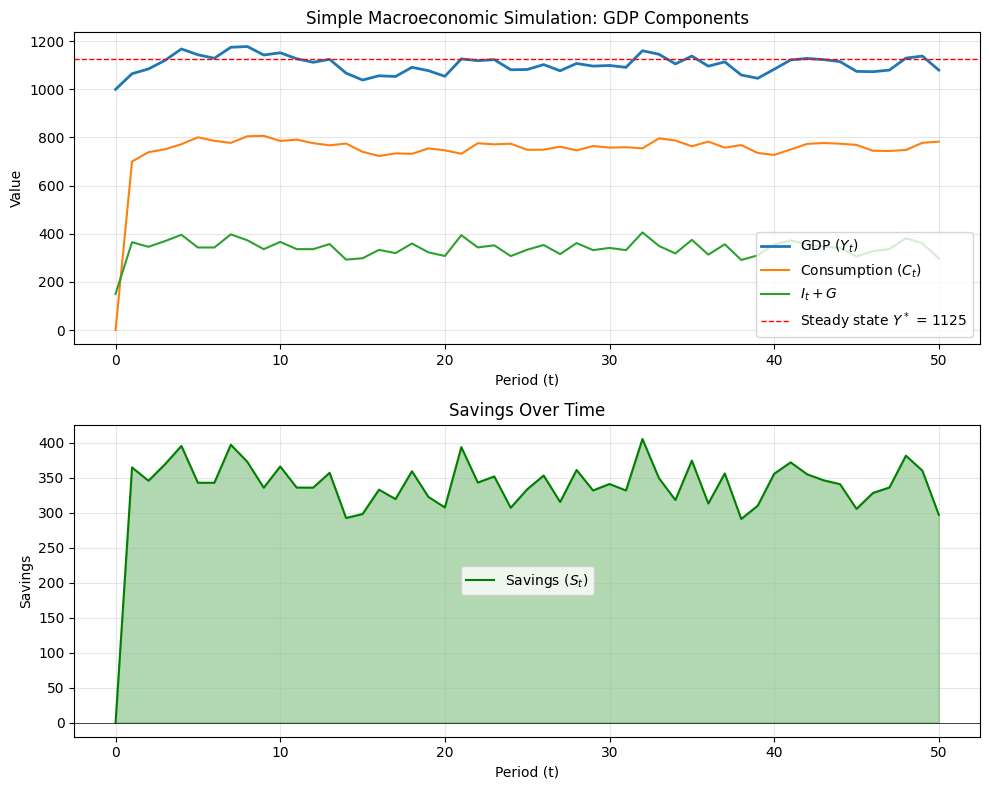

Plot saved as simulation_plot.png


In [36]:
# --- Solution ---
import numpy as np
import matplotlib.pyplot as plt

def initialise_economy(Y0, c0, c1, I_bar, G_bar, sigma, T):
    economy = {
        "Y0": Y0, "c0": c0, "c1": c1,
        "I_bar": I_bar, "G_bar": G_bar, "sigma": sigma, "T": T,
        "Y": np.zeros(T + 1),
        "C": np.zeros(T + 1),
        "I": np.zeros(T + 1),
        "S": np.zeros(T + 1),
    }
    economy["Y"][0] = Y0
    return economy

def simulate(economy, seed=42):
    np.random.seed(seed)
    T = economy["T"]
    c0, c1 = economy["c0"], economy["c1"]
    I_bar, G, sigma = economy["I_bar"], economy["G_bar"], economy["sigma"]
    Y, C, I, S = economy["Y"], economy["C"], economy["I"], economy["S"]
    for t in range(1, T + 1):
        C[t] = c0 + c1 * Y[t - 1]
        I[t] = I_bar + np.random.normal(0, sigma)
        Y[t] = C[t] + I[t] + G
        S[t] = Y[t] - C[t]
    return economy

econ = initialise_economy(Y0=1000, c0=100, c1=0.6, I_bar=200, G_bar=150, sigma=30, T=50)
econ = simulate(econ, seed=42)

T = econ["T"]
t_axis = np.arange(T + 1)
Y = econ["Y"]
C = econ["C"]
IG = econ["I"] + econ["G_bar"]  # Investment + Government spending
S = econ["S"]
Y_star = (econ["c0"] + econ["I_bar"] + econ["G_bar"]) / (1 - econ["c1"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top panel: GDP, Consumption, I+G
ax1.plot(t_axis, Y, label="GDP ($Y_t$)", linewidth=2)
ax1.plot(t_axis, C, label="Consumption ($C_t$)", linewidth=1.5)
ax1.plot(t_axis, IG, label="$I_t + G$", linewidth=1.5)
ax1.axhline(y=Y_star, color='red', linestyle='--', linewidth=1, label=f"Steady state $Y^*$ = {Y_star:.0f}")
ax1.set_xlabel("Period (t)")
ax1.set_ylabel("Value")
ax1.set_title("Simple Macroeconomic Simulation: GDP Components")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom panel: Savings
ax2.plot(t_axis, S, label="Savings ($S_t$)", color='green', linewidth=1.5)
ax2.fill_between(t_axis, S, 0, alpha=0.3, color='green')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel("Period (t)")
ax2.set_ylabel("Savings")
ax2.set_title("Savings Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("simulation_plot.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot saved as simulation_plot.png")


*End of Problem Set A.*